In [1]:
# ============================================
# IMPORTS
# ============================================
import os
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, TensorBoard

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix, classification_report

2026-05-07 15:10:50.694784: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778166650.883744      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778166650.937841      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778166651.394748      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778166651.394788      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778166651.394791      23 computation_placer.cc:177] computation placer alr

In [2]:
# ============================================
# SETTINGS
# ============================================

IMG_SIZE = (224, 224)

BATCH_SIZE = 32

INITIAL_EPOCHS = 15
FINE_TUNE_EPOCHS = 15

NUM_CLASSES = 4

train_dir = "/kaggle/input/datasets/mistblade69/brisc-dataset2025/brisc2025/classification_task/train"
test_dir = "/kaggle/input/datasets/mistblade69/brisc-dataset2025/brisc2025/classification_task/test"

In [3]:
# ============================================
# DATA GENERATORS
# ============================================

train_datagen = ImageDataGenerator(
    rescale=1./255,

    validation_split=0.2,

    rotation_range=20,
    zoom_range=0.15,

    horizontal_flip=True
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

In [4]:
# ============================================
# TRAIN DATA
# ============================================

train_dataset = train_datagen.flow_from_directory(

    train_dir,

    target_size=IMG_SIZE,

    batch_size=BATCH_SIZE,

    class_mode='categorical',

    subset='training',

    shuffle=True
)

# ============================================
# VALIDATION DATA
# ============================================

validation_dataset = train_datagen.flow_from_directory(

    train_dir,

    target_size=IMG_SIZE,

    batch_size=BATCH_SIZE,

    class_mode='categorical',

    subset='validation',

    shuffle=False
)

# ============================================
# TEST DATA
# ============================================

test_dataset = test_datagen.flow_from_directory(

    test_dir,

    target_size=IMG_SIZE,

    batch_size=BATCH_SIZE,

    class_mode='categorical',

    shuffle=False
)

print(train_dataset.class_indices)

Found 4002 images belonging to 4 classes.
Found 998 images belonging to 4 classes.
Found 1000 images belonging to 4 classes.
{'glioma': 0, 'meningioma': 1, 'no_tumor': 2, 'pituitary': 3}


In [5]:
# ============================================
# LOAD MOBILENETV2
# ============================================

base_model = MobileNetV2(

    weights='imagenet',

    include_top=False,

    input_shape=(224,224,3)
)

base_model.trainable = False

I0000 00:00:1778166678.520155      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [6]:
# ============================================
# BUILD MODEL
# ============================================

inputs = tf.keras.Input(shape=(224,224,3))

x = base_model(inputs, training=False)

x = layers.GlobalAveragePooling2D()(x)

x = layers.BatchNormalization()(x)

x = layers.Dense(256, activation='relu')(x)

x = layers.Dropout(0.3)(x)

outputs = layers.Dense(
    NUM_CLASSES,
    activation='softmax'
)(x)

model = tf.keras.Model(inputs, outputs)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,592,068 (9.89 MB)

 Trainable params: 331,524 (1.26 MB)

 Non-trainable params: 2,260,544 (8.62 MB)

In [7]:
# ============================================
# COMPILE MODEL
# ============================================

model.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-4
    ),

    loss='categorical_crossentropy',

    metrics=['accuracy']
)

In [8]:
# ============================================
# CALLBACKS
# ============================================

early_stopping = EarlyStopping(

    monitor='val_loss',

    patience=5,

    restore_best_weights=True,

    verbose=1
)

reduce_lr = ReduceLROnPlateau(

    monitor='val_loss',

    factor=0.2,

    patience=2,

    min_lr=1e-7,

    verbose=1
)

checkpoint = ModelCheckpoint(

    "best_mobilenetv2.keras",

    monitor='val_accuracy',

    save_best_only=True,

    verbose=1
)

tensorboard = TensorBoard(
    log_dir='logs'
)

callbacks = [

    early_stopping,

    reduce_lr,

    checkpoint,

    tensorboard
]

In [9]:
# ============================================
# INITIAL TRAINING
# ============================================

history = model.fit(

    train_dataset,

    validation_data=validation_dataset,

    epochs=INITIAL_EPOCHS,

    callbacks=callbacks
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15


I0000 00:00:1778166687.880099      89 service.cc:152] XLA service 0x7fe8d8001a30 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778166687.880157      89 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1778166689.000649      89 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1778166695.606088      89 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 524ms/step - accuracy: 0.5558 - loss: 1.1348

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()



Epoch 1: val_accuracy improved from -inf to 0.76954, saving model to best_mobilenetv2.keras
126/126 ━━━━━━━━━━━━━━━━━━━━ 106s 734ms/step - accuracy: 0.5568 - loss: 1.1323 - val_accuracy: 0.7695 - val_loss: 0.7215 - learning_rate: 1.0000e-04
Epoch 2/15
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 356ms/step - accuracy: 0.8172 - loss: 0.4803
Epoch 2: val_accuracy improved from 0.76954 to 0.81062, saving model to best_mobilenetv2.keras
126/126 ━━━━━━━━━━━━━━━━━━━━ 56s 448ms/step - accuracy: 0.8173 - loss: 0.4801 - val_accuracy: 0.8106 - val_loss: 0.6403 - learning_rate: 1.0000e-04
Epoch 3/15
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 342ms/step - accuracy: 0.8584 - loss: 0.3753
Epoch 3: val_accuracy did not improve from 0.81062
126/126 ━━━━━━━━━━━━━━━━━━━━ 54s 429ms/step - accuracy: 0.8585 - loss: 0.3753 - val_accuracy: 0.8006 - val_loss: 0.6285 - learning_rate: 1.0000e-04
Epoch 4/15
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 343ms/step - accuracy: 0.8817 - loss: 0.3116
Epoch 4: val_accuracy did not improve from 0.81062
1

In [10]:
# ============================================
# FINE TUNING
# ============================================

base_model.trainable = True

for layer in base_model.layers[:-30]:

    layer.trainable = False

In [11]:
# ============================================
# RECOMPILE AFTER FINE TUNING
# ============================================

model.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-4
    ),

    loss='categorical_crossentropy',

    metrics=['accuracy']
)

In [12]:
# ============================================
# FINE TUNE TRAINING
# ============================================

fine_tune_history = model.fit(

    train_dataset,

    validation_data=validation_dataset,

    epochs=FINE_TUNE_EPOCHS,

    callbacks=callbacks
)

Epoch 1/15


2026-05-07 15:26:30.492424: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-07 15:26:30.689910: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 398ms/step - accuracy: 0.8416 - loss: 0.4091
Epoch 1: val_accuracy did not improve from 0.86172
126/126 ━━━━━━━━━━━━━━━━━━━━ 86s 552ms/step - accuracy: 0.8418 - loss: 0.4084 - val_accuracy: 0.7134 - val_loss: 0.9994 - learning_rate: 1.0000e-04
Epoch 2/15
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 356ms/step - accuracy: 0.9305 - loss: 0.1898
Epoch 2: val_accuracy did not improve from 0.86172
126/126 ━━━━━━━━━━━━━━━━━━━━ 56s 446ms/step - accuracy: 0.9305 - loss: 0.1897 - val_accuracy: 0.7545 - val_loss: 0.8278 - learning_rate: 1.0000e-04
Epoch 3/15
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 356ms/step - accuracy: 0.9619 - loss: 0.1055
Epoch 3: val_accuracy did not improve from 0.86172
126/126 ━━━━━━━━━━━━━━━━━━━━ 56s 445ms/step - accuracy: 0.9619 - loss: 0.1056 - val_accuracy: 0.8036 - val_loss: 0.6876 - learning_rate: 1.0000e-04
Epoch 4/15
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 365ms/step - accuracy: 0.9601 - loss: 0.1079
Epoch 4: val_accuracy did not improve from 0.86172
126/126 ━━━

In [13]:
from tensorflow.keras.models import load_model

model=load_model("best_mobilenetv2.keras")

In [14]:
# ============================================
# EVALUATION
# ============================================

test_loss, test_accuracy = model.evaluate(
    test_dataset
)

print("\nTest Accuracy :", test_accuracy)

print("Test Loss :", test_loss)

32/32 ━━━━━━━━━━━━━━━━━━━━ 17s 384ms/step - accuracy: 0.8777 - loss: 0.4798

Test Accuracy : 0.9110000133514404
Test Loss : 0.3673785626888275


In [15]:
model.save("tumor_mobilenetv2_image.keras")

print("Model saved successfully")

Model saved successfully


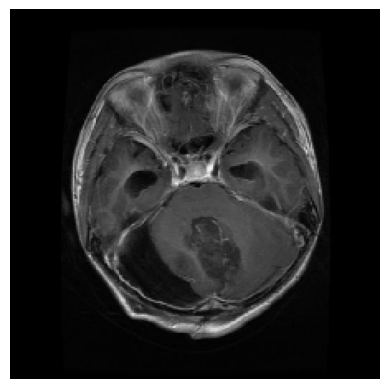

1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
Predicted Class : glioma
Confidence : 100.00%

Class Probabilities:

glioma : 100.00%
meningioma : 0.00%
notumor : 0.00%
pituitary : 0.00%


In [16]:
# ============================================
# SINGLE IMAGE PREDICTION
# ============================================

from tensorflow.keras.preprocessing import image
import tensorflow as tf

# LOAD MODEL
model = tf.keras.models.load_model(
    "best_mobilenetv2.keras"
)

# CLASS NAMES
class_names = [
    "glioma",
    "meningioma",
    "notumor",
    "pituitary"
]

# IMAGE PATH
img_path = "/kaggle/input/datasets/mistblade69/brisc-dataset2025/brisc2025/classification_task/test/glioma/brisc2025_test_00001_gl_ax_t1.jpg"

# LOAD IMAGE
img = image.load_img(
    img_path,
    target_size=(224,224)
)

# DISPLAY IMAGE
plt.imshow(img)
plt.axis("off")
plt.show()

# IMAGE TO ARRAY
img_array = image.img_to_array(img)

# NORMALIZATION
img_array = img_array / 255.0

# ADD BATCH DIMENSION
img_array = np.expand_dims(
    img_array,
    axis=0
)

# PREDICTION
prediction = model.predict(img_array)

# GET CLASS INDEX
predicted_class = np.argmax(
    prediction,
    axis=1
)[0]

# CONFIDENCE
confidence = np.max(prediction)

# OUTPUT
print(
    "Predicted Class :",
    class_names[predicted_class]
)

print(
    "Confidence : {:.2f}%".format(
        confidence * 100
    )
)

# RAW PROBABILITIES
print("\nClass Probabilities:\n")

for i, class_name in enumerate(class_names):

    print(
        f"{class_name} : {prediction[0][i]*100:.2f}%"
    )